## 1. 데이터 전처리: pivoting, melting

In [ ]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset("flights")
df.head()

In [ ]:
df.groupby("year")["passengers"].mean().reset_index()

In [ ]:
df.groupby("month")["passengers"].mean().reset_index()

In [ ]:
pivot_df = df.pivot(
    index="year",
    columns="month",
    values="passengers"
)

pivot_df.head()

In [ ]:
pivot_table_df = pd.pivot_table(
    df,
    index="year",
    columns="month",
    values="passengers",
    aggfunc="mean"
)

pivot_table_df.head()

In [ ]:
pd.pivot_table(
    df,
    index="year",
    values="passengers",
    aggfunc=["mean", "sum", "max"] )

In [ ]:
long_df = pivot_df.reset_index().melt(
    id_vars="year",
    var_name="month",
    value_name="passengers"
)

long_df.head()

## 2. OHE와 LabelEncoding

In [ ]:
import pandas as pd
df = pd.read_csv("creditApprovalUCI.csv")
df1 = df.select_dtypes(include="number")
df2 = df.select_dtypes(exclude="number")
#imputing,,,수치형: 평균, 범주형: 최빈값
from sklearn.impute import SimpleImputer
imputer1 = SimpleImputer(strategy="mean")  #
imputer2 = SimpleImputer(strategy="most_frequent")

df1_imputed = pd.DataFrame( imputer1.fit_transform( df1 ), columns=df1.columns)
df2_imputed = pd.DataFrame( imputer2.fit_transform( df2 ), columns=df2.columns)
df_imputed = pd.concat( [df1_imputed, df2_imputed], axis=1)
df3 = pd.get_dummies(df2_imputed.A4) #OHE, df, 컬럼, 
arr2 = df3.astype("int").values   #2d array #값의 type을 int, values 속성으로 array출력
import numpy as np
pd.DataFrame(np.argmax(arr2, axis=1)).replace({0:"l", 1:"u", 2:"y"})  #OHE->원래대로 변경
#df2_imputed에서 A4 컬럼에 대해 OHE, 원래대로 변경   

In [ ]:
pd.get_dummies(df.A1)
pd.get_dummies(df.A1, drop_first=True)

In [ ]:
#df2_imputed의 A7컬럼에 대해서 LabelEncoder로 인코딩한 결과 데이터프레임으로...해보세요.
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
le = LabelEncoder()#OneHotEncoder(sparse_output=False)
y_encoded = le.fit_transform(df2_imputed[["A7"]]) #fit, transform, fit_transform
print(y_encoded)

## 3. 파티셔닝과 imblearning

In [2]:
import pandas as pd
pd.__version__

'3.0.5'

In [ ]:
#creditset2.csv를 df4로 읽으셔서, 8:2로 파티셔닝
#df4의 loan, age, income을 선택하신 데이터프레임, default10yr를 각각 파티셔닝 해보세요
#X_train, X_test, y_train, y_test결과 할당
df4 = pd.read_csv("creditset2.csv")
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df4[["loan", "age","income"]], 
                        df4.default10yr, train_size=0.8,
                        random_state=1, stratify=df4.default10yr)   

In [ ]:
df4.default10yr.value_counts() #imbalanced 1) stratify 지정 
#### 2)적은 수 범주가 있는 행 늘려주기-> 합성... over sampling
# 합성  Synthetic, Minority, Over Sampling TEc... :SMOTE
#3)많은 수 범주가 있는 행 줄여주기  -> down sampling

In [ ]:
!pip install imblearn -q

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df4[["loan", "age","income"]], 
     df4.default10yr, train_size=0.8, random_state=1, stratify=df4.default10yr)   

In [ ]:
df1 = pd.read_csv("creditset2.csv")
from imblearn.over_sampling import SMOTE, SMOTENC #SMOTEN: 모든 변수가 범주형일때, SMOTENC: 연속형+범주형, 가장 많이 사용
smote = SMOTE(random_state=42, sampling_strategy=0.4)
X_res, y_res = smote.fit_resample(df1[["age", "loan", "income"]], df1.default10yr)
df1.shape, X_res.shape, y_res.shape
y_res.value_counts()     

default10yr
0    1717
1     686
Name: count, dtype: int64

In [ ]:
#data.csv Pass.Fail 컬럼이 타겟, 나머지 X변수, 
#1)일반 파티셔닝, 8:2, stratify 적용
#2)SMOTE, 타겟변수의 1이 0의 65%가 되도록 적용해보세요. 
df5 = pd.read_csv("data.csv")
X = df5.iloc[:, 0:48]
y = df5["Pass.Fail"]
train_test_split( X, y, train_size=0.8, stratify = y, random_state=1)
SMOTE(sampling_strategy=0.65).fit_resample( X, y ) 

In [ ]:
# 1. week1.csv ->passorfail이 타겟, serial, 날짜/시간 컬럼은 제외, imputing->scaling->partitionig
df6 = pd.read_csv("week1.csv")
df6.drop(columns=['SerialNo', 'ReceivedDateTime'], inplace=True)#df6.iloc[:, 2:43]
df6.isnull().mean()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X=df6.drop(columns="passorfail")
y=df6.passorfail
X_scaled = pd.DataFrame( MinMaxScaler().fit_transform( X ), columns=X.columns)
X_train, X_test, y_train,y_test = train_test_split( X_scaled, y )

# 2. 1의 train 부분을 SMOTE 적용
X_train_res, y_train_res = SMOTE().fit_resample( X_train, y_train)

In [ ]:
#agv.zip -> WD ->압축해제 -> agv의 모든 csv를 하나의 데이터프레임으로..
#5번째 컬럼에 정상, 벨트슨함인지를 표현, normal, abnormal
import os
result = []
for i in ["agv\\정상", "agv\\벨트느슨함"]:
    for j in os.listdir(i):         
        tmp = pd.read_csv( i+"\\"+j, skiprows=9, header=None )
        tmp  = tmp.iloc[:, 0:4]
        tmp["target"] = i
        result.append(tmp)

df6 = pd.concat( result, axis=0)
df6["target"] = df6.target.replace( {"agv\\정상":"noraml", "agv\\벨트느슨함":"abnormal"})
#imputing, scaling(Standard), partioning(9:1), target컬럼이 y변수,s
from sklearn.preprocessing import StandardScaler
scaled = StandardScaler().fit_transform( df6.drop(columns="target") )
target_ohe = pd.get_dummies(df6.target)
X_train, X_test, y_train,y_test =train_test_split( scaled, target_ohe, test_size=0.1)

0.9998804780876493

In [31]:
df2 = df.iloc[:, 0:4].dropna()
df2.head()

,A1,A2,A3,A4
0,b,30.83,0.000,u
1,a,58.67,4.460,u
3,b,27.83,1.540,u
4,b,20.17,5.625,u
6,b,33.17,1.040,u


In [ ]:
#category 타입에서는 자동으로 적용
for col in df2.select_dtypes(exclude="number"):
    df2[col] = df2[col].astype('category')

In [38]:
X = df2.iloc[:,1:4]
y = df2.A1
smote2 = SMOTENC(categorical_features="auto", random_state=42)
smote2.fit_resample(X,y)

(            A2         A3 A4
 0    30.830000   0.000000  u
 1    58.670000   4.460000  u
 2    27.830000   1.540000  u
 3    20.170000   5.625000  u
 4    33.170000   1.040000  u
 ..         ...        ... ..
 777  22.040200   1.459800  y
 778  47.234202   2.370763  u
 779  37.977539   1.069273  u
 780  22.500000  10.384929  y
 781  18.858787   4.358649  y
 
 [782 rows x 3 columns],
 0      b
 1      a
 2      b
 3      b
 4      b
       ..
 777    a
 778    a
 779    a
 780    a
 781    a
 Name: A1, Length: 782, dtype: category
 Categories (2, object): ['a', 'b'])

## 4. 폴더 및 파일 처리

In [39]:
# 폴더와 파일 처리
import os
print(os.path.join('usr', 'bin', 'spam'))

usr\bin\spam


In [74]:
os.chdir('C:\\Users\\user\\Documents\\de1')
wd = os.getcwd()
os.chdir('C:\\Users\\user')
os.chdir(wd)


In [76]:
myfiles = ['guests.txt', 'demo.docx']
for filename in myfiles:
	print(os.path.join(wd, "data2", filename))


C:\Users\user\Documents\de1\data2\guests.txt
C:\Users\user\Documents\de1\data2\demo.docx


In [77]:
os.makedirs('test')

In [57]:
os.getcwd()

'C:\\Users\\user\\Documents\\de1\\data2'

In [78]:
os.path.abspath('.')
os.path.abspath('./test')
os.path.isabs('.')
os.path.isabs(os.path.abspath('.'))

True

In [79]:
#파일 복사 및 이동
import shutil	#shell util
shutil.copy('data2/guests.txt', 'test/test1.txt')
#shutil.copytree('../sample_data', 'test_backup')
#moving&renaming
#shutil.move('test_backup', 'test_backup2')

'test/test1.txt'

In [80]:
#file check
for filename in os.listdir('data2'):
	if filename.endswith('.txt'):
		#os.unlink(filename)
		print(filename)

guests.txt


- 현재 워킹디렉토리의 파일들을 리스트업해서 워킹디렉토리 내 test2 폴더를 만든 후에 해당 폴더로 복사
- test2폴더의 파일 중에 .txt로 끝나는 경우, 파일명을 출력

In [81]:
os.chdir("data2")

In [82]:
os.getcwd()
os.makedirs("test2")
for file in os.listdir():
  if file.endswith('.txt'):
    print(file)
    shutil.copy( file, "test2/"+file)     

guests.txt


## 5. 여러 폴더, 여러 파일 읽기

In [ ]:
#data_politics.zip, images2.zip
#data_politics 폴더의 파일들의 이름을 리스트
#폴더별 화자의 파일들을 저장: DON, ROY
#filename에 endswith를 사용
#import shutil
#shutil.copy("원래파일", "옮길곳")

os.getcwd()

052_400011_0327014_DON.txt
052_400011_0327025_DON.txt
052_400011_0327044_DON.txt
052_400011_0327046_DON.txt
052_400011_1479036_DON.txt
052_400011_1479038_DON.txt
052_400011_1479040_DON.txt
052_400011_1479042_DON.txt
052_400011_1479044_DON.txt
052_400011_1479046_DON.txt
052_400011_1479048_DON.txt
052_400011_1479050_DON.txt
052_400011_1479062_DON.txt
052_400011_1479065_DON.txt
052_400011_1479069_DON.txt
052_400080_0327047_DON.txt
052_400080_0327048_DON.txt
052_400080_0327050_DON.txt
052_400080_0327055_DON.txt
052_400170_0327004_DON.txt
052_400170_0327007_DON.txt
052_400199_0327033_DON.txt
052_400199_0327034_DON.txt
052_400199_0327036_DON.txt
052_400199_0327038_DON.txt
052_400199_0327040_DON.txt
052_400199_0327041_DON.txt
052_400199_0327043_DON.txt
052_400230_0327028_DON.txt
052_400283_1479006_DON.txt
052_400283_1479008_DON.txt
052_400283_1479010_DON.txt
052_400283_1479074_DON.txt
052_400283_1479076_DON.txt
052_400283_1479082_DON.txt
052_400283_1479084_DON.txt
052_400283_1479099_DON.txt
1

'c:\\Users\\user\\Documents\\de1'

In [86]:
wd = os.getcwd()

In [121]:
os.makedirs("DON")

In [123]:
import shutil
files = os.listdir("data_politics")
for i in files:
    if i.endswith("DON.txt"):
        shutil.copy("data_politics\\"+i, "DON\\" )

In [89]:
files = os.listdir()

In [90]:
os.makedirs('DON')
print(files)
for i in files:
  if i.endswith('DON.txt'):
    shutil.move(i, "DON/"+i)

#ROY, DMN, RMY, DOY 사람의 파일을 각 폴더로 옮겨보세요.
os.makedirs('DOY')
os.makedirs('RMY')
os.makedirs('ROY')
os.makedirs('DMN')

['052_400011_0327014_DON.txt', '052_400011_0327025_DON.txt', '052_400011_0327044_DON.txt', '052_400011_0327046_DON.txt', '052_400011_1479036_DON.txt', '052_400011_1479038_DON.txt', '052_400011_1479040_DON.txt', '052_400011_1479042_DON.txt', '052_400011_1479044_DON.txt', '052_400011_1479046_DON.txt', '052_400011_1479048_DON.txt', '052_400011_1479050_DON.txt', '052_400011_1479062_DON.txt', '052_400011_1479065_DON.txt', '052_400011_1479069_DON.txt', '052_400033_1479034_DOY.txt', '052_400033_1479097_DOY.txt', '052_400050_0327031_DOY.txt', '052_400077_0327001_ROY.txt', '052_400077_0327002_ROY.txt', '052_400077_0327003_ROY.txt', '052_400077_0327005_ROY.txt', '052_400077_0327008_ROY.txt', '052_400077_0327009_ROY.txt', '052_400080_0327047_DON.txt', '052_400080_0327048_DON.txt', '052_400080_0327050_DON.txt', '052_400080_0327055_DON.txt', '052_400095_1479070_ROY.txt', '052_400095_1479071_ROY.txt', '052_400095_1479079_ROY.txt', '052_400095_1479080_ROY.txt', '052_400095_1479086_ROY.txt', '052_4001

In [91]:
#keyword_data.zip  대상
#keyword_data의 폴더별 파일들을 하나의 새로운 폴더로 이동
#이동 시에는 각 파일명 앞에, 해당 파일이 속해있던 폴더명을 포함
#keyword_data 폴더는 자동으로 생성하고, 속하는 파일은 일부만 업로드

os.chdir("../keyword_data")

In [92]:
os.mkdir("target")

In [93]:
for i in ['1', '2', '3']:
  for j in ['1', '2', '3']:
    for q in ['1', '2']:
      tmp = 'k'+i+'_'+j+'_'+q
      for t in os.listdir(tmp):
        shutil.move(tmp+"/"+t, "target/"+tmp+"_"+t)

In [94]:
os.listdir()

['k1_1_1',
 'k1_1_2',
 'k1_2_1',
 'k1_2_2',
 'k1_3_1',
 'k1_3_2',
 'k2_1_1',
 'k2_1_2',
 'k2_2_1',
 'k2_2_2',
 'k2_3_1',
 'k2_3_2',
 'k3_1_1',
 'k3_1_2',
 'k3_2_1',
 'k3_2_2',
 'k3_3_1',
 'k3_3_2',
 'k4_1_1',
 'k4_2_1',
 'k4_3_1',
 'target']

In [107]:
import glob
glob.glob("*/*")

['k4_1_1\\000000_0',
 'k4_1_1\\000001_0',
 'k4_1_1\\000002_0',
 'k4_1_1\\000003_0',
 'k4_1_1\\000004_0',
 'k4_1_1\\000005_0',
 'k4_1_1\\000006_0',
 'k4_1_1\\000007_0',
 'k4_1_1\\000008_0',
 'k4_1_1\\000009_0',
 'k4_1_1\\000010_0',
 'k4_1_1\\000011_0',
 'k4_1_1\\000012_0',
 'k4_1_1\\000013_0',
 'k4_1_1\\000014_0',
 'k4_1_1\\000015_0',
 'k4_1_1\\000016_0',
 'k4_1_1\\000017_0',
 'k4_1_1\\000018_0',
 'k4_1_1\\000019_0',
 'k4_1_1\\000020_0',
 'k4_1_1\\000021_0',
 'k4_1_1\\000022_0',
 'k4_1_1\\000023_0',
 'k4_1_1\\000024_0',
 'k4_1_1\\000025_0',
 'k4_1_1\\000026_0',
 'k4_1_1\\000027_0',
 'k4_1_1\\000028_0',
 'k4_1_1\\000029_0',
 'k4_1_1\\000030_0',
 'k4_1_1\\000031_0',
 'k4_1_1\\000032_0',
 'k4_1_1\\000033_0',
 'k4_1_1\\000034_0',
 'k4_1_1\\000035_0',
 'k4_1_1\\000036_0',
 'k4_1_1\\000037_0',
 'k4_1_1\\000038_0',
 'k4_1_1\\000039_0',
 'k4_1_1\\000040_0',
 'k4_1_1\\000041_0',
 'k4_1_1\\000042_0',
 'k4_1_1\\000043_0',
 'k4_1_1\\000044_0',
 'k4_1_1\\000045_0',
 'k4_1_1\\000046_0',
 'k4_1_1\\000

## 6. 이미지 처리

In [ ]:
!pip install pillow

In [148]:
# opencv, PIL
# images2의 카테고리별 이미지 파일들을 읽으셔서 array로 변환 후에 리스트에 저장해주세요
# 각 이미지의 카테고리 정보도 별도의 리스트에 저장해보세요.
import os
import numpy
from PIL import Image
imglist = []
label = []
for i in os.listdir("images2"):
    for j in os.listdir("images2\\"+i+"\\"):
        img = Image.open("images2\\"+i+"\\"+j)
        img = img.convert("RGB").resize( (10,10)  )
        arr  =np.array(img).reshape(300)/255  #MinMaxScaling 
        imglist.append(arr)
        label.append(i)

In [ ]:
df7 = pd.DataFrame( imglist )
df7["target"] = label #target변수
X_train, X_test, y_train, y_test = train_test_split(df7.drop(columns="target"), 
                                                    df7.target)
rf = RandomForestClassifier().fit(X_train, y_train)

['flamingo' 'elephant' 'camera' 'elephant' 'butterfly']


183        chair
97        camera
202        chair
203     elephant
4      butterfly
Name: target, dtype: str

In [ ]:
os.chdir('..')
os.getcwd()

'C:\\Users\\user\\Documents\\de1'

In [113]:
# Python Image Library를 이용한 이미지 처리: 크롭핑, 리사이즈, 크기 조정 등
import os
from PIL import Image
catIm = Image.open('zophie.png')
catIm.size
width, height = catIm.size
catIm.filename
catIm.format
catIm.save('zophie.jpg')

In [114]:
#Cropping
croppedIm = catIm.crop( (335,345,565,560))
croppedIm
croppedIm.save('cropped.png')

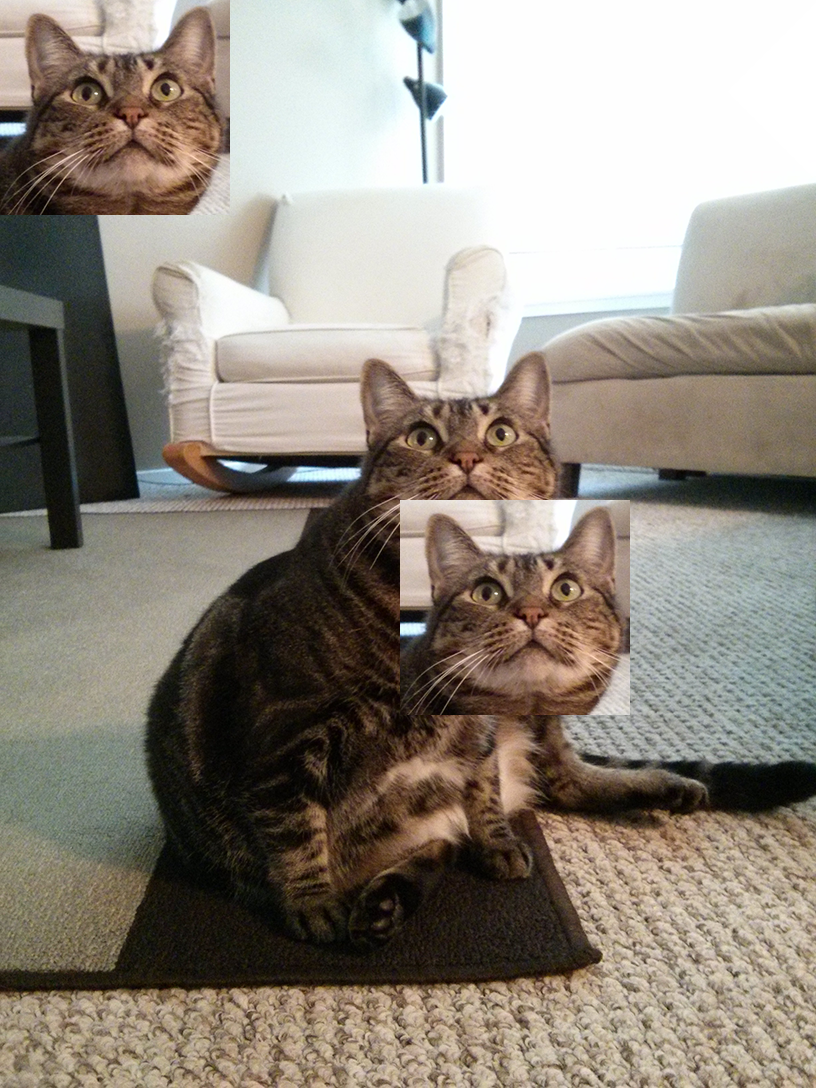

In [115]:
catCopyIm = catIm.copy()
faceIM = catIm.crop( (335,345, 565, 560))
catCopyIm.paste(faceIM, (0,0))
catCopyIm.paste( faceIM, (400,500))
catCopyIm.save('pasted.png')
catCopyIm

In [116]:
#복수의 이미지
files=os.listdir()
print(files)

['cropped.png', 'data2', 'data_politics', 'data_politics.zip', 'keyword_data', 'keyword_data.zip', 'pasted.png', 'test', 'zophie.jpg', 'zophie.png']


In [117]:
for i in files:
  print(i)
  if i.endswith(".png") | i.endswith(".jpg"):
    temp = Image.open(i)
    print(temp.filename,temp.size)
    temp2 = temp.resize( (100, 100) )
    temp2.save("resize_"+temp.filename)

cropped.png
cropped.png (230, 215)
data2
data_politics
data_politics.zip
keyword_data
keyword_data.zip
pasted.png
pasted.png (816, 1088)
test
zophie.jpg
zophie.jpg (816, 1088)
zophie.png
zophie.png (816, 1088)


-  MNIST 이미지

In [119]:
!pip install scikit-learn -q

- Caltech101 데이터 처리 및 분류 적용

In [123]:
# images2 압축해제한 폴더 지정
os.chdir("images2")
os.mkdir("result")
os.getcwd()

'C:\\Users\\user\\Documents\\de1\\images2'

In [124]:
#/content/caltech/result 폴더에 저장하기
categories = ["camera", "chair"]
for i in categories:
  files = os.listdir( i )
  q=1
  for j in files:
    img = Image.open(i+"/"+j)
    img.resize( (50, 50) )
    img.save("result/"+i+"_resized_"+str(q)+".jpg")
    q=q+1

In [125]:
# 이미지 데이터 처리
#https://www.vision.caltech.edu/Image_Datasets/Caltech101/Caltech101.html
#압축 해제 후  img(현재 홈 디렉토리) 밑에  101_ObjectCategories 폴더로 업로드
#필요한 카테고리만 업로드

from PIL import Image
import os, glob
import numpy as np
from sklearn.model_selection import train_test_split

#대상 카테고리
caltech_dir="images2"
categories = ["camera", "chair", "flamingo"]
nb_classes = len(categories)

#image size
image_w=64
image_h=64
pixels = image_w * image_h * 3

#read
X=[]
Y=[]
categories

['camera', 'chair', 'flamingo']

In [126]:
np.array(img)

array([[[255, 255, 253],
        [254, 254, 252],
        [251, 253, 252],
        ...,
        [249, 253, 254],
        [252, 254, 253],
        [253, 255, 254]],

       [[255, 255, 253],
        [254, 254, 252],
        [251, 253, 252],
        ...,
        [249, 253, 254],
        [252, 254, 253],
        [253, 255, 254]],

       [[255, 255, 253],
        [254, 254, 252],
        [251, 253, 252],
        ...,
        [249, 253, 254],
        [252, 254, 253],
        [253, 255, 254]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [127]:
os.chdir("..")
for idx, cat in enumerate( categories):

  #label
  label=[0 for i in range(nb_classes)]
  label[idx]=1

  #image
  image_dir=caltech_dir+"/"+cat
  files = glob.glob(image_dir+"/*.jpg")
  print(image_dir)
  for i, f in enumerate(files):
    img = Image.open(f)
    img = img.convert("RGB")
    img = img.resize((image_w, image_h))
    data=np.array(img)
    X.append(data)
    Y.append(label)
    if i%10 ==0:
      print(i, "\n", data)

X=np.array(X)
Y=np.array(Y)

print(X.shape)

#partition
X_train, X_test, y_train, y_test = train_test_split( X,Y)


images2/camera
0 
 [[[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 ...

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]]
10 
 [[[254 254 254]
  [254 254 254]
  [254 254 254]
  ...
  [254 254 254]
  [254 254 254]
  [254 254 254]]

 [[254 254 254]
  [254 254 254]
  [254 254 254]
  ...
  [254 254 254]
  [254 254 254]
  [254 254 254]]

 [[254 254 254]
  [254 254 254]
  [254 254 254]
  ...
  [254 254 254]
  [254 254 254]
  [254 254 254]]

 ...

 [[254 254 254]
  [254 254 2

## 7. 다양한 데이터 읽고 쓰기

- 엑셀: pandas의 read_excel 등

In [130]:
os.chdir('C:\\Users\\user\\Documents\\de1')
os.getcwd()

'C:\\Users\\user\\Documents\\de1'

In [131]:
os.chdir("data2")
os.getcwd()

'C:\\Users\\user\\Documents\\de1\\data2'

In [133]:
# 스프레드시트 다루기
!pip install openpyxl -q

In [138]:
import openpyxl
wb = openpyxl.load_workbook('example.xlsx')
sheet = wb['Sheet1']
sheet
sheet.title
sheet['A1'].value

datetime.datetime(2015, 4, 5, 13, 34, 2)

In [139]:
sheet['A1'].value
c=sheet['B1']
c.value
str(c.row)
c.column

sheet.cell(row=1, column=2).value

for i in range(1,8,2):
	print(i, sheet.cell(row=i, column=2).value)

1 Apples
3 Pears
5 Apples
7 Strawberries


In [ ]:
#import openpyxl, pprint
wb = openpyxl.load_workbook('censuspopdata.xlsx')
sheet = wb['Population by Census Tract']

In [141]:
countyData = {}

for row in range(2, sheet.max_row+1):
	state=sheet['B'+str(row)].value
	county=sheet['C'+str(row)].value
	pop=sheet['D'+str(row)].value
	countyData.setdefault(state, {})
	countyData[state].setdefault(county, {'tracts':0, 'pop':0})
	countyData[state][county]['tracts'] +=1
	countyData[state][county]['pop'] +=int(pop)

countyData['AK']['Anchorage']['pop']

291826

- PDF 파일

In [142]:
#extracting text from pdf
!pip install pypdf

In [143]:
from pypdf import PdfReader

reader = PdfReader("meetingminutes.pdf")

print("pages:", len(reader.pages))


pages: 19


In [144]:
text = ""
for i, page in enumerate(reader.pages):
    page_text = page.extract_text()
    if page_text:
        text += f"\n--- page {i+1} ---\n"
        text += page_text

print(text[:1000])


--- page 1 ---
OOFFFFIICCIIAALL  BBOOAARRDD  MMIINNUUTTEESS  
 
Meeting of March 7, 2014 
 
 
 
 
 
 
 
 
 
  
 
The Board of Elementary and Secondary Education shall provide leadership and 
create policies for education that expand opportunities for children, empower 
families and communities, and advance Louisiana in an increasingly 
competitive global market. 
BOARD  
of 
ELEMENTARY 
and  
SECONDARY 
EDUCATION 
 
--- page 2 ---
 LOUISIANA STATE BOARD OF ELEMENTARY AND SECONDARY EDUCATION 
 
 MARCH 7, 2014 
 
 The Louisiana Purchase Room 
 Baton Rouge, LA 
 
 
 
 
The Louisiana State Board of Elementary and Secondary Education met in regular  
session on March 7, 2014, in the Louisiana Purchase Room, located in the Claiborne 
Building in Baton Rouge, Louisiana.  The meeting was called to order at 9:17 a.m.  by 
Board President Chas Roemer and opened with a prayer by Ms. Terry Johnson, Bossier 
Parish School System. 
 
Board members present were Dr. Lottie Beebe, Ms. Holly Boffy, Mr.

In [145]:
pages_1_to_3 = [
    reader.pages[i].extract_text()
    for i in range(3)
]

text = "\n".join(pages_1_to_3)

In [146]:
meta = reader.metadata
print(meta)

print("Title:", meta.title)
print("Author:", meta.author)
print("Created:", meta.creation_date)

{'/Author': 'bfreiber', '/CreationDate': "D:20140415103213-05'00'", '/Creator': 'Acrobat PDFMaker 10.1 for Word', '/ModDate': "D:20140415103213-05'00'", '/Producer': 'Adobe PDF Library 10.0', '/Title': ''}
Title: None
Author: bfreiber
Created: 2014-04-15 10:32:13-05:00


In [147]:
#파일 분할
from pypdf import PdfReader, PdfWriter
for i, page in enumerate(reader.pages):
    writer = PdfWriter()
    writer.add_page(page)

    with open(f"page_{i+1}.pdf", "wb") as f:
        writer.write(f)

In [148]:
#파일 병합
import os
files = os.listdir()
writer = PdfWriter()

for i in files:
  if i.endswith(".pdf"):
    reader = PdfReader(i)
    for page in reader.pages:
        writer.add_page(page)

with open("merged.pdf", "wb") as f:
    writer.write(f)

- word

In [150]:
#Word
!pip install python-docx -q

In [151]:
import docx
doc = docx.Document('demo.docx')
len(doc.paragraphs)
doc.paragraphs[0].text
doc.paragraphs[1].runs[0].text

'A plain paragraph with'

In [152]:
def getText(filename):
	doc = docx.Document(filename)
	fullText = []
	for para in doc.paragraphs:
		fullText.append(para.text)
	return '\n'.join(fullText)

getText('demo.docx')

'Document Title\nA plain paragraph with some bold and some italic\nHeading, level 1\nIntense quote\nfirst item in unordered list\nfirst item in ordered list\n'

- JSON

In [159]:
# JSON 다루기
import json
#stringsOfJsonData='{"name":"Zophie","isCat":true,"miceCaught":0, "felineIQ":'None'}'	#decoding error
stringsOfJsonData='''
{
  "name": "Zophie",
  "isCat": true,
  "miceCaught": 0,
  "felineIQ": null
}
'''
jsonDataAsPythonValue=json.loads(stringsOfJsonData)
jsonDataAsPythonValue

{'name': 'Zophie', 'isCat': True, 'miceCaught': 0, 'felineIQ': None}

In [160]:
pythonValue = {"name":"Zophie","isCat":True, "miceCaught":0, "felineIQ":None}
stringsOfJsonData = json.dumps( pythonValue)
stringsOfJsonData

'{"name": "Zophie", "isCat": true, "miceCaught": 0, "felineIQ": null}'

In [155]:
with open("cat.json", "w", encoding="utf-8") as f:
    json.dump(pythonValue, f)

with open("cat.json", "w", encoding="utf-8") as f:
    json.dump(pythonValue, f, indent=2, ensure_ascii=False)

In [156]:
import json

with open("cat.json", "r", encoding="utf-8") as f:
    data = json.load(f)

data["miceCaught"] += 1

with open("cat.json", "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2)

In [ ]:
#binary.csv에서 rank별로 json별도로 생성
#rank1인 json만 읽어서 데이터프레임으로 만들어보세요.
import pandas as pd
df8 = pd.read_csv("binary.csv")
for i in [1,2,3,4]:
    df8.query("rank==@i"
    ).to_json("data"+str(i)+".json", orient="records")

pd.read_json("data1.json")
df8.to_dict(orient="records")

NameError: name 'pd' is not defined

In [157]:
import pandas as pd
df = pd.DataFrame([data, data])
print(df)

     name  isCat  miceCaught felineIQ
0  Zophie   True           1     None
1  Zophie   True           1     None


In [158]:
df.to_json("data.json", orient="records") 

In [159]:
import json
import pandas as pd

pythonValue = '''
[
  {
    "id": 1,
    "params": {"C": 1.0, "seed": 42},
    "metrics": {"auc": 0.81}
  },
  {
    "id": 2,
    "params": {"C": 0.5, "seed": 43},
    "metrics": {"auc": 0.79}
  }
]
'''

# 문자열 → Python 객체
data = json.loads(pythonValue)

# JSON 파일로 저장
with open("test.json", "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2, ensure_ascii=False)

# DataFrame으로 읽기
df = pd.read_json("test.json")
print(df)

   id                  params        metrics
0   1  {'C': 1.0, 'seed': 42}  {'auc': 0.81}
1   2  {'C': 0.5, 'seed': 43}  {'auc': 0.79}


- 파퀘(Parquet): 대용량 분석·ML용으로 컬럼 단위로 저장하는 고성능 데이터 포맷

In [ ]:
#Parquet 읽고 쓰기
!pip install pyarrow fastparquet -q

In [14]:
import pandas as pd
df = pd.DataFrame({"id":[1,2,3], "score":[0.8,0.6,0.9], "label":[1,0,1]})
df.to_parquet("example.parquet")   
print(pd.read_parquet("example.parquet"))

   id  score  label
0   1    0.8      1
1   2    0.6      0
2   3    0.9      1


In [15]:
import pandas as pd

df = pd.DataFrame({
    "id": [1, 2, 3],
    "score": [0.8, 0.6, 0.9],
    "label": [1, 0, 1]
})

# 쓰기
df.to_parquet("example.parquet", engine="pyarrow", index=False)

# 읽기
df2 = pd.read_parquet("example.parquet", engine="pyarrow")

print(df2)

   id  score  label
0   1    0.8      1
1   2    0.6      0
2   3    0.9      1


In [163]:
#일부 컬럼만 익기
cols = ["id", "score"]
df = pd.read_parquet("example.parquet", columns=cols)

In [164]:
#필터링 해서 읽기
import pyarrow.parquet as pq

table = pq.read_table(
    "example.parquet",
    filters=[("label", "==", 1)]
)

df_pos = table.to_pandas()

In [165]:
import pyarrow.parquet as pq

pf = pq.ParquetFile("example.parquet")

print("row groups:", pf.num_row_groups)
print("rows:", pf.metadata.num_rows)
print("schema:", pf.schema)

row groups: 1
rows: 3
schema: <pyarrow._parquet.ParquetSchema object at 0x000001C9CA7F5200>
required group field_id=-1 schema {
  optional int64 field_id=-1 id;
  optional double field_id=-1 score;
  optional int64 field_id=-1 label;
}



In [166]:
import pandas as pd
import numpy as np

n = 1000
rng = np.random.default_rng(42)

df = pd.DataFrame({
    "id": np.arange(1, n + 1, dtype="int64"),
    "age": rng.integers(20, 65, size=n, dtype="int16"),
    "income": rng.normal(0.5, 0.15, size=n).astype("float32"),
    "treatment": rng.integers(0, 2, size=n, dtype="int8"),
})

df["group"] = pd.Series(
    rng.choice(["A", "B"], size=n, p=[0.55, 0.45]),
    dtype="category"
)

# outcome 생성 (처치 효과 약간 포함)
logit = (
    0.03 * df["age"]
    + 0.8 * df["income"]
    + 0.6 * df["treatment"]
)
p = 1 / (1 + np.exp(-logit))
df["outcome"] = (rng.random(n) < p).astype("int8")

df["date"] = pd.to_datetime(
    rng.choice(pd.date_range("2024-01-01", "2024-01-31"), size=n)
)

# Parquet 저장
df.to_parquet(
    "sample_research.parquet",
    engine="pyarrow",
    index=False
)

print("saved: sample_research.parquet")
print(df.head())


saved: sample_research.parquet
   id  age    income  treatment group  outcome       date
0   1   26  0.485861          0     A        0 2024-01-02
1   2   24  0.236341          0     A        1 2024-01-28
2   3   64  0.279943          1     B        1 2024-01-26
3   4   54  0.819387          0     A        1 2024-01-26
4   5   64  0.306887          0     B        1 2024-01-13


In [167]:
import pandas as pd

df = pd.read_parquet("sample_research.parquet")

print(df.dtypes)
print(df.head())


id                    int64
age                   int16
income              float32
treatment              int8
group              category
outcome                int8
date         datetime64[ns]
dtype: object
   id  age    income  treatment group  outcome       date
0   1   26  0.485861          0     A        0 2024-01-02
1   2   24  0.236341          0     A        1 2024-01-28
2   3   64  0.279943          1     B        1 2024-01-26
3   4   54  0.819387          0     A        1 2024-01-26
4   5   64  0.306887          0     B        1 2024-01-13


In [5]:
import pyarrow.parquet as pq

pf = pq.ParquetFile("sample_research.parquet")
print("rows:", pf.metadata.num_rows)
print("row groups:", pf.num_row_groups)
print("schema:")
print(pf.schema)


FileNotFoundError: [Errno 2] Failed to open local file 'sample_research.parquet'. Detail: [errno 2] No such file or directory

In [ ]:

import pyarrow
pyarrow.__version__

'25.0.0'

- 웹 읽기

In [171]:
!pip install requests -q

In [1]:
import requests
res = requests.get('http://www.naver.com')
print('결과: ', res.status_code) #200은 정상적인 접속

결과:  200


In [172]:
import requests
res = requests.get('https://www.naver.com/abcdefg')
print('결과 : ', res.status_code) #400수준 코드는 접속 불가

결과 :  404


In [173]:
import requests
res = requests.get('http://naver.com')
print('결과: ', res.status_code)

if res.status_code == requests.codes.ok:
  print('ok')
else :
  print("error code:",res.status_code)

결과:  200
ok


In [174]:
import requests
res = requests.get('http://naver.com')
print('결과 : ', res.status_code)

res.raise_for_status() #res가 정상이 아닌 경우 오류
print('crawling start')

결과 :  200
crawling start


In [2]:
import requests
res = requests.get('http://naver.com')
res.raise_for_status()

res.text

'   <!doctype html> <html lang="ko" class="fzoom"> <head> <meta charset="utf-8"> <meta name="Referrer" content="origin"> <meta http-equiv="X-UA-Compatible" content="IE=edge"> <meta name="viewport" content="width=1190"> <title>NAVER</title> <meta name="apple-mobile-web-app-title" content="NAVER"/> <meta name="robots" content="index,nofollow"/> <meta name="description" content="네이버 메인에서 다양한 정보와 유용한 컨텐츠를 만나 보세요"/> <meta property="og:title" content="네이버"> <meta property="og:url" content="https://www.naver.com/"> <meta property="og:image" content="https://s.pstatic.net/static/www/mobile/edit/2016/0705/mobile_212852414260.png"> <meta property="og:description" content="네이버 메인에서 다양한 정보와 유용한 컨텐츠를 만나 보세요"/> <meta name="twitter:card" content="summary"> <meta name="twitter:title" content=""> <meta name="twitter:url" content="https://www.naver.com/"> <meta name="twitter:image" content="https://s.pstatic.net/static/www/mobile/edit/2016/0705/mobile_212852414260.png"> <meta name="twitter:description" 

In [176]:
import requests
res = requests.get('http://google.com')
res.raise_for_status()

with open('crawl1.html','w', encoding = 'utf-8') as f:
  f.write(res.text)


- beautifulsoup : HTML 파싱을 위한 라이브러리

In [ ]:
!pip install beautifulsoup4  -q
!pip install lxml -q        
#lxml: 빠르고 대용량 크롤링 유리
#html5lib: 브라우저와 가장 유사하게 파싱
#html.parse: 기본 파서

In [3]:
import requests
from bs4 import BeautifulSoup

url = 'https://comic.naver.com/webtoon/weekday.nhn'
res = requests.get(url)
res.raise_for_status()

soup = BeautifulSoup(res.text, "html.parser") #lxml
soup



<!DOCTYPE html>

<html lang="ko">
<head>
<title>네이버 웹툰</title>
<link href="https://shared-comic.pstatic.net/favicon/favicon_96x96.ico" rel="icon" type="image/x-icon"/>
<link href="https://ssl.pstatic.net/static/wcc/kw-owner/prod-1.0/index.css?v=202608041440" rel="stylesheet" type="text/css">
<link href="https://m.comic.naver.com/webtoon/weekday" rel="canonical"/>
<meta content="6Wv2YrpTSpapViVikuUS-ebAqZDiKxcrDV_clkRzH9A" name="google-site-verification"/>
<meta charset="utf-8"/>
<meta content="ie=edge" http-equiv="x-ua-compatible"/>
<meta content="article" property="og:type"/>
<meta content="네이버 웹툰" property="og:article:author"/>
<meta content="https://comic.naver.com" property="og:article:author:url"/>
<meta content="네이버 웹툰" property="og:title"/>
<meta content="https://ssl.pstatic.net/static/comic/images/og_tag_v3.png" property="og:image"/>
<meta content="매일매일 새로운 재미, 네이버 웹툰." property="og:description"/>
<script>
		if (/MSIE \d|Trident.*rv:/.test(navigator.userAgent)) {
			window.loc

In [179]:
soup.title

<title>네이버 웹툰</title>

In [180]:
soup.title.get_text() #해당 태그에 대한 텍스트값

'네이버 웹툰'

- 주가정보

In [4]:
import csv
import requests
from bs4 import BeautifulSoup

url = 'https://finance.naver.com/sise/sise_market_sum.nhn?sosok=0&page='

for page in range(1,2):
  res = requests.get(url + str(page))
  res.raise_for_status()
  soup = BeautifulSoup(res.text, 'lxml')


  data_rows = soup.find('table',attrs={'class':'type_2'}).find('tbody').find_all('tr')
  for row in data_rows:
    columns = row.find_all('td')
    data = [column.get_text().strip() for column in columns]
    print(data)


['']
['1', '삼성전자', '237,250', '하락\n\t\t\t\t2,250', '-0.94%', '100', '13,870,296', '5,846,279', '46.61', '24,232,187', '19.18', '10.85', '']
['2', 'SK하이닉스', '1,554,000', '하락\n\t\t\t\t13,000', '-0.83%', '5,000', '11,351,851', '730,492', '51.04', '4,351,052', '15.01', '44.15', '']
['3', '삼성전자우', '174,600', '하락\n\t\t\t\t3,400', '-1.91%', '100', '1,400,940', '802,371', '76.99', '2,024,278', '14.11', 'N/A', '']
['4', 'SK스퀘어', '1,039,000', '상승\n\t\t\t\t14,000', '+1.37%', '100', '1,371,048', '131,958', '46.11', '768,821', '8.82', '37.82', '']
['5', '삼성전기', '1,181,000', '보합0', '0.00%', '5,000', '882,133', '74,694', '39.44', '837,329', '111.55', '7.70', '']
['']
['']
['']
['6', '현대차', '387,750', '하락\n\t\t\t\t5,250', '-1.34%', '5,000', '793,948', '204,758', '25.09', '573,184', '11.95', '8.41', '']
['7', 'LG에너지솔루션', '326,500', '상승\n\t\t\t\t10,500', '+3.32%', '500', '764,010', '234,000', '5.54', '190,628', '-47.66', '-5.19', '']
['8', '삼성바이오로직스', '1,462,000', '상승\n\t\t\t\t39,000', '+2.74%', '2,500'

In [182]:
import csv
import requests
from bs4 import BeautifulSoup

url = 'https://finance.naver.com/sise/sise_market_sum.nhn?sosok=0&page='

for page in range(1,2):
  res = requests.get(url + str(page))
  res.raise_for_status()
  soup = BeautifulSoup(res.text, 'lxml')


  data_rows = soup.find('table',attrs={'class':'type_2'}).find('tbody').find_all('tr')
  for row in data_rows:
    columns = row.find_all('td')
    if len(columns) <=1: #비어있는 라인 제외시키기
      continue
    data = [column.get_text().strip() for column in columns]
    print(data)


['1', '삼성전자', '239,500', '하락\n\t\t\t\t23,000', '-8.76%', '100', '14,001,837', '5,846,279', '46.70', '27,393,580', '19.36', '10.85', '']
['2', 'SK하이닉스', '1,567,000', '하락\n\t\t\t\t151,000', '-8.79%', '5,000', '11,446,815', '730,492', '51.22', '5,429,182', '15.14', '44.15', '']
['3', '삼성전자우', '178,000', '하락\n\t\t\t\t13,000', '-6.81%', '100', '1,428,221', '802,371', '77.04', '3,132,086', '14.39', 'N/A', '']
['4', 'SK스퀘어', '1,025,000', '하락\n\t\t\t\t13,000', '-1.25%', '100', '1,352,573', '131,958', '46.16', '819,005', '8.70', '37.82', '']
['5', '삼성전기', '1,181,000', '상승\n\t\t\t\t39,000', '+3.42%', '5,000', '882,133', '74,694', '39.65', '1,107,138', '111.55', '7.70', '']
['6', '현대차', '393,000', '상승\n\t\t\t\t5,000', '+1.29%', '5,000', '804,698', '204,758', '25.05', '826,843', '12.12', '8.41', '']
['7', 'LG에너지솔루션', '316,000', '하락\n\t\t\t\t12,000', '-3.66%', '500', '739,440', '234,000', '5.55', '279,360', '-46.12', '-5.19', '']
['8', '삼성바이오로직스', '1,423,000', '하락\n\t\t\t\t62,000', '-4.18%', '2,500

## 8. 데이터 파이프라인 만들기

- 직렬 파이프: Pipeline([ ("step1", A()), ("step2", B()), ("step3", C())]) 에서 A.fit_transform, B.fit_transform, C.fit의 순서로 실행
- 중간 단계는 모두 Transformer, 마지막 단계는 모형 가능
- imputer->scaler->model
- nested pipepline

In [ ]:
os.chdir("..") #'C:\\Users\\user\\Documents\\de1'
os.getcwd()

'C:\\Users\\user\\Documents\\de1'

In [186]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
import pickle

# 1) CSV 읽기
csv_path = "data.csv"      # <- 파일명 수정
target_col = "Pass.Fail"      # <- 타깃 컬럼명 수정

df = pd.read_csv(csv_path)

X = df.drop(columns=[target_col])
y = df[target_col]

# 2) Train/Test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y if y.nunique() <= 20 else None  # 분류(클래스 수 적음)면 stratify
)

# 3) 전처리(결측치 + 스케일링 + 원핫)
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, selector(dtype_include="number")),
        ("cat", categorical_transformer, selector(dtype_exclude="number"))
    ],
    remainder="drop"
)

# 4) 모델 포함 전체 파이프라인
# 분류 예시(로지스틱 회귀). 회귀면 LogisticRegression 대신 Ridge/LinearRegression 등으로 교체
model = LogisticRegression(max_iter=1000)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

# 학습
clf.fit(X_train, y_train)




,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [187]:
#피클로 저장
with open("pipeline.pkl", "wb") as f:
    pickle.dump(
        {
            "pipeline": clf,
            "target_col": target_col,
            "feature_columns": list(X.columns),
        },
        f
    )

print("Saved: pipeline.pkl")


Saved: pipeline.pkl


In [188]:
# 저장된 파이프라인 로드해서 예측

with open("pipeline.pkl", "rb") as f:
     saved = pickle.load(f)
pipe = saved["pipeline"]
preds = pipe.predict(X_test)
proba = pipe.predict_proba(X_test)[:, 1]  # 분류일 때


## 9. API 쓰기 및 읽기, streamlit

- 다음은 .py로 워킹디렉토리에 저장
- 아나콘다 프롬프트에서 
- pip install fastapi[standard] streamlit
- streamlit run streamlit파일.py
- fastapi run fastapi파일.py

In [ ]:
#pip install fastapi[standard]
#binary.csv 서비스하는 api, parameter값은 몇 행을 출력하는지 결정
#fastapi run api2.py
from fastapi import FastAPI
import pandas as pd
df = pd.read_csv("binary.csv")
app = FastAPI()
@app.get("/data")
def data(row:int):
    return df.sample(row).to_dict(orient="records")
#vs코드에서 api2.py에 pd.read_json으로 읽으셔서 결과를 데이터프레임으로 만드세요

In [22]:
pd.read_json("http://localhost:8000/data?row=5")

,admit,gre,gpa,rank
0,0,780,3.87,4
1,0,520,2.70,3
2,0,460,3.07,2
3,0,760,3.35,3
4,0,720,3.40,3


In [21]:
import requests
#r = requests.get("http://localhost:8000/data")
df10 = pd.read_json("http://localhost:8000/data")

In [ ]:
from fastapi import FastAPI
app = FastAPI()
@app.get("/health")
def health():
    return {"status": "ok"}

@app.get("/predict")
def predict(x: float, y: float):
    return {
        "x": x,
        "y": y,
        "result": x + y
    }

- streamlit :  파이썬 코드로 웹앱 도구

In [ ]:
#streamlit --version
#streamlit run 파이썬.py 파일
#http://localhost:8501

In [ ]:
#다음을 py파일로 저장
import streamlit as st

st.title("기본 UI 예제")

name = st.text_input("이름을 입력하세요")
age = st.slider("나이", 0, 100, 25)

if st.button("확인"):
    st.write(f"이름: {name}, 나이: {age}")


In [ ]:
#다음을 py파일로 저장
import streamlit as st
import pandas as pd

df = pd.DataFrame({
    "x": [1, 2, 3],
    "y": [10, 20, 30]
})

st.subheader("데이터프레임")
st.dataframe(df)


In [ ]:
#다음을 py파일로 저장
import streamlit as st
import numpy as np
import pandas as pd

data = pd.DataFrame(
    np.random.randn(100, 2),
    columns=["x", "y"]
)

st.line_chart(data)


In [ ]:
#py로 저장
import streamlit as st
import pickle
import numpy as np

# 미리 저장된 모델 로드
with open("model.pkl", "rb") as f:
    model = pickle.load(f)

st.title("모델 예측 데모")

x1 = st.number_input("x1", 0.0)
x2 = st.number_input("x2", 0.0)

if st.button("예측"):
    pred = model.predict([[x1, x2]])
    st.write("예측 결과:", pred[0])
